House counts per price range:
 price_range
0-25L       32
26-50L     318
51-75L     148
76-100L     39
>100L        8
Name: count, dtype: int64


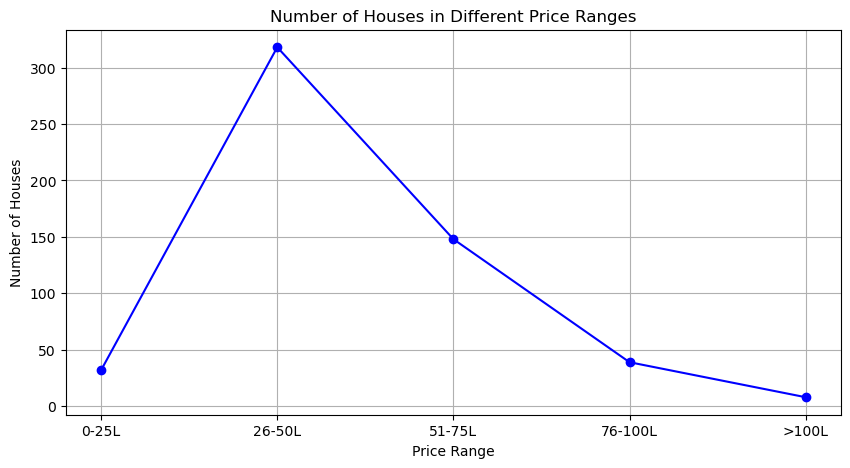


Average price for AC vs Non-AC:
 airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64


C:\Users\priya\AppData\Local\Temp\ipykernel_27524\1531063395.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_ac.index, y=avg_price_ac.values, palette='viridis')


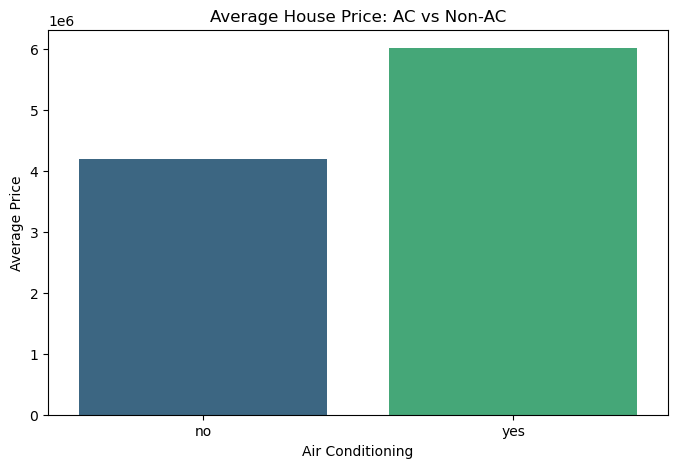

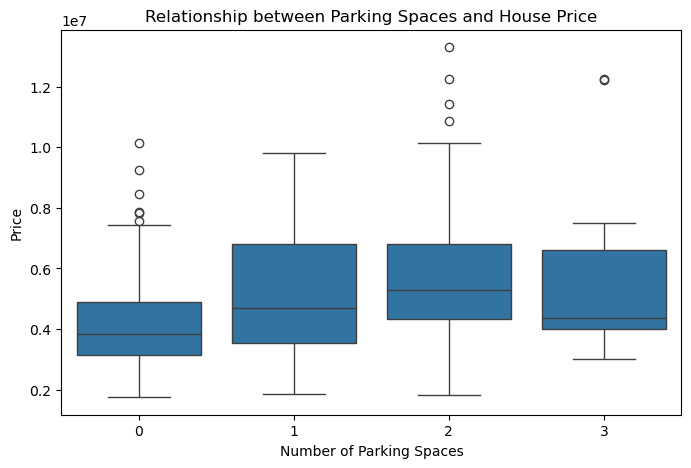


Average Price (Group A: <5000sqft, no prefarea): 3,827,671.56
Average Price (Group B: >5000sqft, prefarea): 6,546,807.69
The Price Gap is: 2,719,136.13


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Ensure Housing.csv is in the same directory as this script
df = pd.read_csv('Housing.csv')

# ---------------------------------------------------------
# 1. House Price Ranges & Line Chart 
# ---------------------------------------------------------
# Defining the bins and labels for price ranges (in lakhs)
# Note: The CSV prices are in absolute numbers (e.g., 13300000)
bins = [0, 2500000, 5000000, 7500000, 10000000, float('inf')]
labels = ['0-25L', '26-50L', '51-75L', '76-100L', '>100L']

df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)
price_counts = df['price_range'].value_counts().reindex(labels)

print("House counts per price range:\n", price_counts)

plt.figure(figsize=(10, 5))
plt.plot(price_counts.index, price_counts.values, marker='o', linestyle='-', color='b')
plt.title('Number of Houses in Different Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Number of Houses')
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 2. Average Price for AC vs. Non-AC & Bar Chart 
# ---------------------------------------------------------
avg_price_ac = df.groupby('airconditioning')['price'].mean()

print("\nAverage price for AC vs Non-AC:\n", avg_price_ac)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_price_ac.index, y=avg_price_ac.values, palette='viridis')
plt.title('Average House Price: AC vs Non-AC')
plt.xlabel('Air Conditioning')
plt.ylabel('Average Price')
plt.show()

# ---------------------------------------------------------
# 3. Relationship between Parking and House Price 
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x='parking', y='price', data=df)
plt.title('Relationship between Parking Spaces and House Price')
plt.xlabel('Number of Parking Spaces')
plt.ylabel('Price')
plt.show()

# ---------------------------------------------------------
# 4. Price Gap Analysis 
# ---------------------------------------------------------
# Group A: <5000sqft & no prefarea
group_a = df[(df['area'] < 5000) & (df['prefarea'] == 'no')]
avg_a = group_a['price'].mean()

# Group B: >5000sqft & there is prefarea
group_b = df[(df['area'] > 5000) & (df['prefarea'] == 'yes')]
avg_b = group_b['price'].mean()

price_gap = avg_b - avg_a

print(f"\nAverage Price (Group A: <5000sqft, no prefarea): {avg_a:,.2f}")
print(f"Average Price (Group B: >5000sqft, prefarea): {avg_b:,.2f}")
print(f"The Price Gap is: {price_gap:,.2f}")